In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('../data/cleaned_uts_data.csv')
df.head()

,Booking_ID,Date,Month,Week,Time,Ticket_Type,Booking_Mode,From_Station,To_Station,Passengers,Total_Fare,Payment_Type,Railway_Line,City,Day_Name,Is_Weekend,Hour,Fare_Per_Passenger
0,80428,2025-07-12,Jul,28,5:30:24,Single,Paper,Byculla,Cst,2,30,Upi,Central,Mumbai,Saturday,1,5,15.0
1,29465,2025-01-13,Jan,3,11:03:16,Monthly Pass,Paperless,Marine Lines,Dadar,2,0,Cash,Western,Mumbai,Monday,0,11,0.0
2,82739,2025-10-25,Oct,43,0:55:13,Single,Paperless,Borivali,Dadar,4,60,Debit Card,Western,Mumbai,Saturday,1,0,15.0
3,35534,2025-12-14,Dec,51,5:53:37,Single,Paperless,Borivali,Marine Lines,1,15,Credit Card,Western,Mumbai,Sunday,1,5,15.0
4,64116,2025-12-24,Dec,52,7:18:24,Return,Paperless,Cst,Kurla,1,30,Upi,Central,Mumbai,Wednesday,0,7,30.0


In [2]:
print("Total Valid Bookings:", len(df))
print("Total Passengers Commuted:", df['Passengers'].sum())
print("Total Fare Collection: ₹", df['Total_Fare'].sum())
print("Average Fare per Passenger: ₹", round(df['Fare_Per_Passenger'].mean(), 2))

Total Valid Bookings: 89959
Total Passengers Commuted: 225482
Total Fare Collection: ₹ 3375885
Average Fare per Passenger: ₹ 15.0


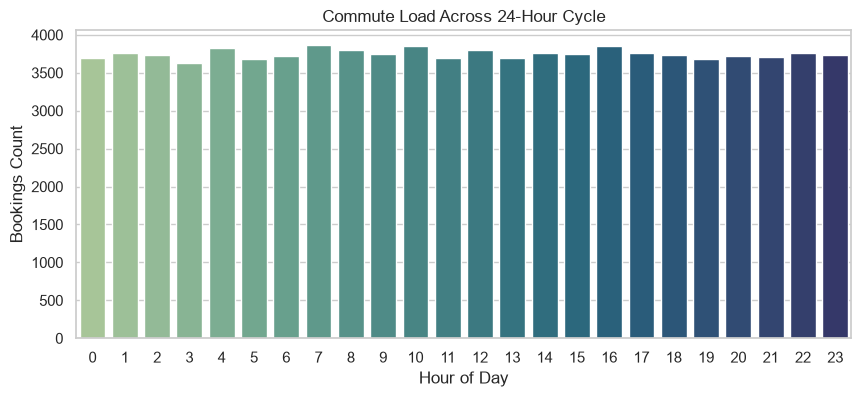

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Hour", hue="Hour", palette="crest", legend=False)
plt.title("Commute Load Across 24-Hour Cycle")
plt.xlabel("Hour of Day")
plt.ylabel("Bookings Count")
plt.show()

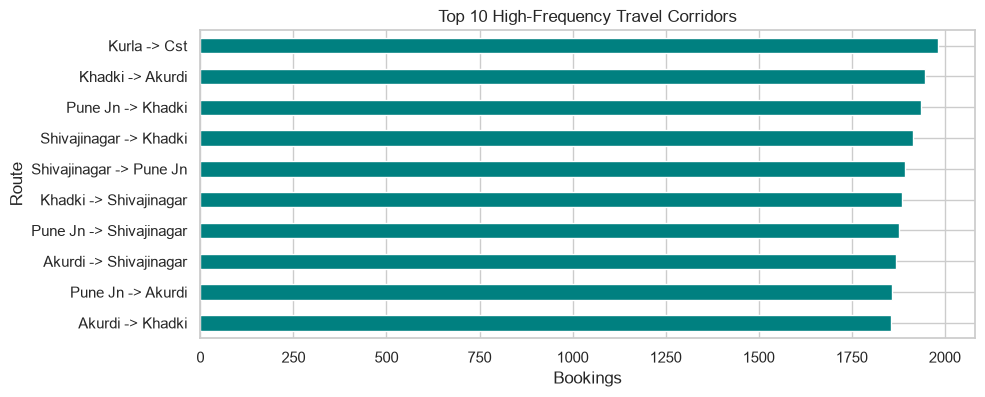

In [4]:
df['Route'] = df['From_Station'] + " -> " + df['To_Station']
top_10 = df['Route'].value_counts().head(10)

plt.figure(figsize=(10, 4))
top_10.plot(kind='barh', color='teal').invert_yaxis()
plt.title("Top 10 High-Frequency Travel Corridors")
plt.xlabel("Bookings")
plt.show()

In [ ]:
# --- CUSTOM INPUT TESTER ---
# Change these values to test any stations or hours:
my_source = "Thane"
my_destination = "Cst"
my_hour = 9  # 9 AM

# Filter data dynamically
custom_result = df[
    (df['From_Station'].str.lower() == my_source.lower()) & 
    (df['To_Station'].str.lower() == my_destination.lower())
]

print(f"=== Results for Route: {my_source.title()} -> {my_destination.title()} ===")
print(f"Total Historical Bookings : {len(custom_result):,}")
print(f"Total Commuters Transported: {custom_result['Passengers'].sum():,}")
print(f"Average Fare Paid          : ₹{round(custom_result['Fare_Per_Passenger'].mean(), 2)}")

# Peak commute window for this specific route
if not custom_result.empty:
    busiest_hour = custom_result['Hour'].mode()[0]
    print(f"Busiest Travel Hour        : {busiest_hour}:00 hrs")
else:
    print("No records found matching this route.")